In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os # File and directory operations
import glob # Search files using wildcard patterns
import h5py # Read HDF5 battery dataset
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-02-20_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-12_batchdata_updated_struct_errorcorrect.mat


## Collect Cycle Life Across All Cells

Today, I move from analyzing individual cells to exploring all cells in the dataset. The goal is to load all batch files, read the cycle life for every cell, and organize the results into one DataFrame.

In [3]:
mat_files = glob.glob("/kaggle/input/**/*.mat", recursive=True)

mat_files

['/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat',
 '/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-02-20_batchdata_updated_struct_errorcorrect.mat',
 '/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat',
 '/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-12_batchdata_updated_struct_errorcorrect.mat']

In [4]:
for file in mat_files:
    print(file)

/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-02-20_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-12_batchdata_updated_struct_errorcorrect.mat


In [5]:
def read_scalar_from_ref(f, ref):
    value = np.array(f[ref]).squeeze()
    return float(value)

In [6]:
test_file = mat_files[0]

cycle_lives = []

with h5py.File(test_file, "r") as f:
    num_cells = f["batch"]["cycle_life"].shape[0]
    print("Number of cells:", num_cells)
    
    for cell_index in range(num_cells):
        ref = f["batch"]["cycle_life"][cell_index, 0]
        life = read_scalar_from_ref(f, ref)
        cycle_lives.append(life)

cycle_lives[:10]

Number of cells: 46


[1190.0, 1179.0, 1177.0, 1226.0, 1227.0, 1074.0, 636.0, 870.0, 879.0, 1054.0]

In [7]:
test_cycle_life_df = pd.DataFrame({
    "cell_index": range(len(cycle_lives)),
    "cycle_life": cycle_lives
})

test_cycle_life_df.head()

,cell_index,cycle_life
0,0,1190.0
1,1,1179.0
2,2,1177.0
3,3,1226.0
4,4,1227.0


### The combined cycle life table includes cells from all available batch files. Each row represents one battery cell and contains the batch file name, cell index, and cycle life.

In [8]:
all_cells = []

for file_path in mat_files:
    batch_name = os.path.basename(file_path)
    
    with h5py.File(file_path, "r") as f:
        num_cells = f["batch"]["cycle_life"].shape[0]
        
        for cell_index in range(num_cells):
            ref = f["batch"]["cycle_life"][cell_index, 0]
            life = read_scalar_from_ref(f, ref)
            
            all_cells.append({
                "batch_file": batch_name,
                "cell_index": cell_index,
                "cycle_life": life
            })

cycle_life_all_df = pd.DataFrame(all_cells)

cycle_life_all_df.head()

,batch_file,cell_index,cycle_life
0,2017-05-12_batchdata_updated_struct_errorcorre...,0,1190.0
1,2017-05-12_batchdata_updated_struct_errorcorre...,1,1179.0
2,2017-05-12_batchdata_updated_struct_errorcorre...,2,1177.0
3,2017-05-12_batchdata_updated_struct_errorcorre...,3,1226.0
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0


In [9]:
cycle_life_all_df.shape

(141, 3)

In [10]:
cycle_life_all_df["batch_file"].value_counts()

batch_file
2018-02-20_batchdata_updated_struct_errorcorrect.mat              47
2017-05-12_batchdata_updated_struct_errorcorrect.mat              46
2018-04-12_batchdata_updated_struct_errorcorrect.mat              46
2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat     2
Name: count, dtype: int64

In [11]:
cycle_life_all_df["cycle_life"].describe()

count     129.000000
mean      833.689922
std       314.972737
min       392.000000
25%       559.000000
50%       828.000000
75%      1017.000000
max      1935.000000
Name: cycle_life, dtype: float64

In [12]:
cycle_life_all_df.sort_values("cycle_life").head(10)

,batch_file,cell_index,cycle_life
65,2018-02-20_batchdata_updated_struct_errorcorre...,19,392.0
52,2018-02-20_batchdata_updated_struct_errorcorre...,6,393.0
61,2018-02-20_batchdata_updated_struct_errorcorre...,15,396.0
67,2018-02-20_batchdata_updated_struct_errorcorre...,21,408.0
76,2018-02-20_batchdata_updated_struct_errorcorre...,30,412.0
51,2018-02-20_batchdata_updated_struct_errorcorre...,5,416.0
48,2018-02-20_batchdata_updated_struct_errorcorre...,2,424.0
77,2018-02-20_batchdata_updated_struct_errorcorre...,31,425.0
60,2018-02-20_batchdata_updated_struct_errorcorre...,14,426.0
74,2018-02-20_batchdata_updated_struct_errorcorre...,28,437.0


In [13]:
cycle_life_all_df.sort_values("cycle_life").tail(10)

,batch_file,cell_index,cycle_life
81,2018-02-20_batchdata_updated_struct_errorcorre...,35,NaN
82,2018-02-20_batchdata_updated_struct_errorcorre...,36,NaN
83,2018-02-20_batchdata_updated_struct_errorcorre...,37,NaN
84,2018-02-20_batchdata_updated_struct_errorcorre...,38,NaN
85,2018-02-20_batchdata_updated_struct_errorcorre...,39,NaN
86,2018-02-20_batchdata_updated_struct_errorcorre...,40,NaN
93,2018-04-03_varcharge_batchdata_updated_struct_...,0,NaN
94,2018-04-03_varcharge_batchdata_updated_struct_...,1,NaN
118,2018-04-12_batchdata_updated_struct_errorcorre...,23,NaN
127,2018-04-12_batchdata_updated_struct_errorcorre...,32,NaN


In [12]:
cycle_life_all_df.to_csv("cycle_life_all_cells.csv", index=False)

In [13]:
os.listdir("/kaggle/working")### Cycle Life Table Across All Cells

['cycle_life_all_cells.csv', '.virtual_documents']

### Cycle Life Table Across All Cells

I collected the cycle life values for all cells across the available batch files. Each row in the table represents one battery cell and includes the batch file name, cell index, and cycle life.

This table will be used in the next steps to plot the distribution of lifetimes and to compare early-cycle discharge curve changes against lifetime.

## Distribution of Battery Cycle Lives

Today, I use the cycle life table created from all available cells to understand the distribution of battery lifetimes. The goal is to see how spread out the cycle lives are across the dataset before computing voltage-curve features.

In [14]:
cycle_life_all_df.head()

,batch_file,cell_index,cycle_life
0,2017-05-12_batchdata_updated_struct_errorcorre...,0,1190.0
1,2017-05-12_batchdata_updated_struct_errorcorre...,1,1179.0
2,2017-05-12_batchdata_updated_struct_errorcorre...,2,1177.0
3,2017-05-12_batchdata_updated_struct_errorcorre...,3,1226.0
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0


In [15]:
# checking if there are any missing values
cycle_life_all_df.isna().sum()

batch_file     0
cell_index     0
cycle_life    12
dtype: int64

In [16]:
cycle_life_all_df = cycle_life_all_df.dropna(subset=["cycle_life"])

In [17]:
cycle_life_all_df["cycle_life"].describe()

count     129.000000
mean      833.689922
std       314.972737
min       392.000000
25%       559.000000
50%       828.000000
75%      1017.000000
max      1935.000000
Name: cycle_life, dtype: float64

In [24]:
print("Number of cells:", len(cycle_life_all_df))
print("Shortest cycle life:", cycle_life_all_df["cycle_life"].min())
print("Longest cycle life:", cycle_life_all_df["cycle_life"].max())
print("Average cycle life:", cycle_life_all_df["cycle_life"].mean())
print("Median cycle life:", cycle_life_all_df["cycle_life"].median())

Number of cells: 129
Shortest cycle life: 392.0
Longest cycle life: 1935.0
Average cycle life: 833.6899224806201
Median cycle life: 828.0


### Distribution of Battery Cycle Lives

This histogram shows the distribution of cycle lives across all available battery cells. The x-axis represents cycle life, and the y-axis represents the number of cells in each lifetime range.

The cycle lives are spread across a wide range, which means different cells degrade at different rates. This spread is important for the battery lifetime prediction project because the model needs to learn why some cells last longer than others.

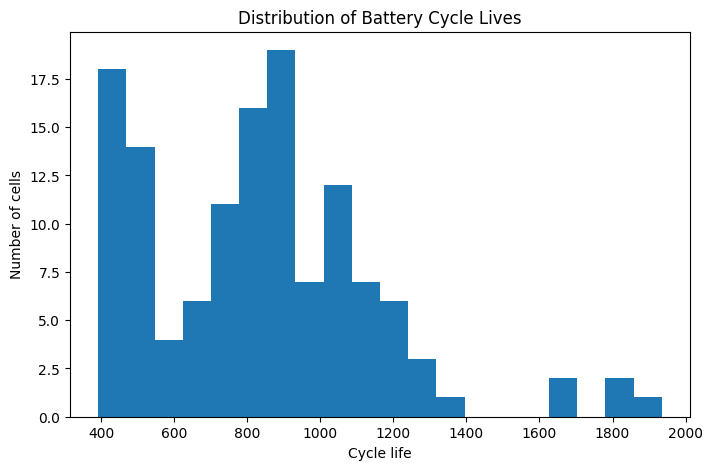

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(cycle_life_all_df["cycle_life"], bins=20)

plt.xlabel("Cycle life")
plt.ylabel("Number of cells")
plt.title("Distribution of Battery Cycle Lives")

plt.show()

In [26]:
cycle_life_all_df.sort_values("cycle_life").head(10)

,batch_file,cell_index,cycle_life
65,2018-02-20_batchdata_updated_struct_errorcorre...,19,392.0
52,2018-02-20_batchdata_updated_struct_errorcorre...,6,393.0
61,2018-02-20_batchdata_updated_struct_errorcorre...,15,396.0
67,2018-02-20_batchdata_updated_struct_errorcorre...,21,408.0
76,2018-02-20_batchdata_updated_struct_errorcorre...,30,412.0
51,2018-02-20_batchdata_updated_struct_errorcorre...,5,416.0
48,2018-02-20_batchdata_updated_struct_errorcorre...,2,424.0
77,2018-02-20_batchdata_updated_struct_errorcorre...,31,425.0
60,2018-02-20_batchdata_updated_struct_errorcorre...,14,426.0
74,2018-02-20_batchdata_updated_struct_errorcorre...,28,437.0


In [27]:
cycle_life_all_df.sort_values("cycle_life").tail(10)

,batch_file,cell_index,cycle_life
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0
97,2018-04-12_batchdata_updated_struct_errorcorre...,2,1267.0
128,2018-04-12_batchdata_updated_struct_errorcorre...,33,1284.0
112,2018-04-12_batchdata_updated_struct_errorcorre...,17,1315.0
132,2018-04-12_batchdata_updated_struct_errorcorre...,37,1390.0
111,2018-04-12_batchdata_updated_struct_errorcorre...,16,1638.0
137,2018-04-12_batchdata_updated_struct_errorcorre...,42,1642.0
140,2018-04-12_batchdata_updated_struct_errorcorre...,45,1801.0
102,2018-04-12_batchdata_updated_struct_errorcorre...,7,1836.0
133,2018-04-12_batchdata_updated_struct_errorcorre...,38,1935.0


In [28]:
cycle_life_all_df["batch_file"].value_counts()

batch_file
2017-05-12_batchdata_updated_struct_errorcorrect.mat    46
2018-04-12_batchdata_updated_struct_errorcorrect.mat    44
2018-02-20_batchdata_updated_struct_errorcorrect.mat    39
Name: count, dtype: int64

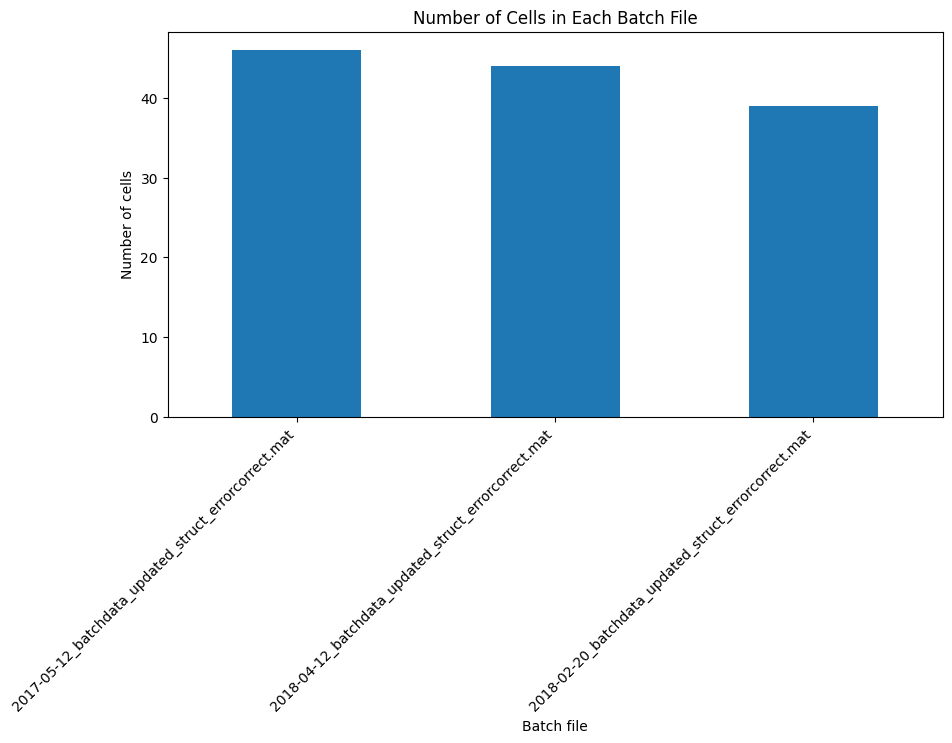

In [29]:
plt.figure(figsize=(10, 5))

cycle_life_all_df["batch_file"].value_counts().plot(kind="bar")

plt.xlabel("Batch file")
plt.ylabel("Number of cells")
plt.title("Number of Cells in Each Batch File")
plt.xticks(rotation=45, ha="right")

plt.show()

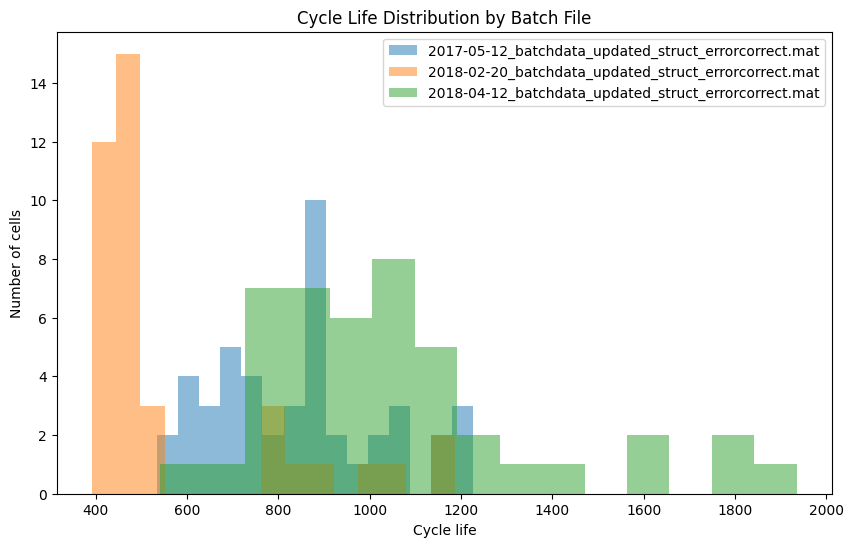

In [19]:
plt.figure(figsize=(10, 6))

for batch_file in cycle_life_all_df["batch_file"].unique():
    subset = cycle_life_all_df[cycle_life_all_df["batch_file"] == batch_file]
    plt.hist(subset["cycle_life"], bins=15, alpha=0.5, label=batch_file)

plt.xlabel("Cycle life")
plt.ylabel("Number of cells")
plt.title("Cycle Life Distribution by Batch File")
plt.legend()
plt.show()

### Observation

The cycle life table shows that the dataset contains cells with a wide range of lifetimes. Some cells have much shorter cycle lives, while others last for many more cycles. This lifetime spread is important because it creates the target variation needed for prediction.

This step helps me understand the dataset at the population level before computing the paper's central voltage-curve feature.

### Compute ΔQ100-10(V) for One Cell 
Today, I compute the discharge curve change between Cycle 100 and Cycle 10 for one battery cell. The goal is to understand the paper's central feature before applying it to all cells.



In [22]:
batch1_path = "/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat"

cell_index = 0

In [23]:
with h5py.File(batch1_path, "r") as f:
    cycles_ref = f["batch"]["cycles"][cell_index, 0]
    cycles = f[cycles_ref]
    
    print(list(cycles.keys()))

['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']


In [24]:
def get_cycle_data(f, cell_index, cycle_index, key):
    cycles_ref = f["batch"]["cycles"][cell_index, 0]
    cycles = f[cycles_ref]
    
    data_ref = cycles[key][cycle_index, 0]
    data = np.array(f[data_ref]).squeeze()
    
    return data

In [25]:
cycle_10_index = 9
cycle_100_index = 99

with h5py.File(batch1_path, "r") as f:
    Qdlin_10 = get_cycle_data(f, cell_index, cycle_10_index, "Qdlin")
    Qdlin_100 = get_cycle_data(f, cell_index, cycle_100_index, "Qdlin")

print("Qdlin Cycle 10 shape:", Qdlin_10.shape)
print("Qdlin Cycle 100 shape:", Qdlin_100.shape)

print("First 10 values of Qdlin Cycle 10:")
print(Qdlin_10[:10])

print("First 10 values of Qdlin Cycle 100:")
print(Qdlin_100[:10])

Qdlin Cycle 10 shape: (1000,)
Qdlin Cycle 100 shape: (1000,)
First 10 values of Qdlin Cycle 10:
[-3.97257678e-04 -3.55843677e-04 -3.16687484e-04 -2.79586958e-04
 -2.44339957e-04 -2.10744338e-04 -1.78597960e-04 -1.47698681e-04
 -1.17844358e-04 -8.88328505e-05]
First 10 values of Qdlin Cycle 100:
[-3.42485952e-04 -3.12880194e-04 -2.83174714e-04 -2.53379074e-04
 -2.23502837e-04 -1.93555566e-04 -1.63546823e-04 -1.33486171e-04
 -1.03383172e-04 -7.32473910e-05]


In [26]:
delta_Q = Qdlin_100 - Qdlin_10

print("Delta Q shape:", delta_Q.shape)
print("First 10 values of delta_Q:")
print(delta_Q[:10])

Delta Q shape: (1000,)
First 10 values of delta_Q:
[5.47717264e-05 4.29634822e-05 3.35127695e-05 2.62078834e-05
 2.08371193e-05 1.71887722e-05 1.50511375e-05 1.42125103e-05
 1.44611859e-05 1.55854595e-05]


In [27]:
var_delta_Q = np.var(delta_Q)

print("Variance of delta_Q:", var_delta_Q)

Variance of delta_Q: 9.663600264771342e-06


In [28]:
log_var_delta_Q = np.log10(var_delta_Q)

print("Log10 variance of delta_Q:", log_var_delta_Q)

Log10 variance of delta_Q: -5.014861042960787


### Discharge Curve Change for Cell 0: Cycle 100 - Cycle 10

This plot shows the difference between the discharge curve at Cycle 100 and Cycle 10 for Cell 0. The x-axis represents the voltage grid index, and the y-axis represents ΔQ100-10(V), which is calculated as:

ΔQ100-10(V) = Q100(V) - Q10(V)

This plot is a first check to make sure the difference curve was computed correctly. The values are small, but the curve shows that the discharge behavior changed between Cycle 10 and Cycle 100. The shape of this difference curve is important because the paper uses the variance of ΔQ100-10(V) as a feature for predicting battery cycle life.

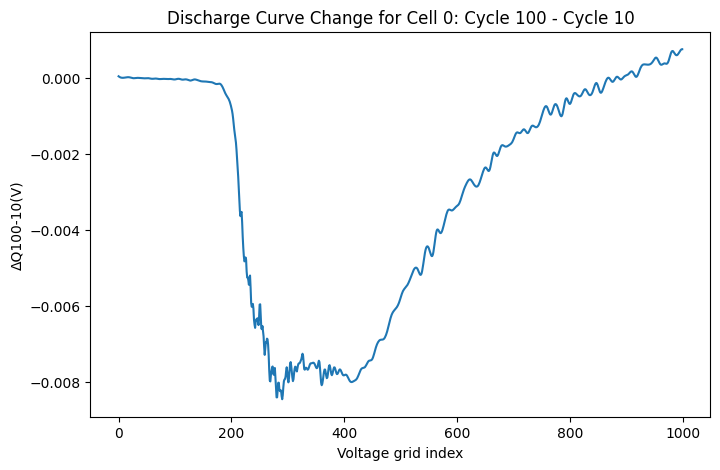

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(delta_Q)

plt.xlabel("Voltage grid index")
plt.ylabel("ΔQ100-10(V)")
plt.title("Discharge Curve Change for Cell 0: Cycle 100 - Cycle 10")

plt.show()

In [30]:
with h5py.File(batch1_path, "r") as f:
    Vdlin_ref = f["batch"]["Vdlin"][cell_index, 0]
    Vdlin = np.array(f[Vdlin_ref]).squeeze()

print("Vdlin shape:", Vdlin.shape)
print("First 10 Vdlin values:")
print(Vdlin[:10])

Vdlin shape: (1000,)
First 10 Vdlin values:
[3.5        3.4984985  3.496997   3.4954955  3.49399399 3.49249249
 3.49099099 3.48948949 3.48798799 3.48648649]


### ΔQ100-10(V) for Cell 0

This plot shows ΔQ100-10(V) for Cell 0 using voltage as the x-axis. The x-axis represents the aligned voltage grid from `Vdlin`, and the y-axis represents the discharge capacity difference between Cycle 100 and Cycle 10.

Compared with the index-based plot, this version is easier to interpret because it shows where the discharge curve changes occur across the voltage range. The curve shows that the largest difference appears around the middle voltage region, while the difference is smaller near the beginning and end of the voltage range.

For Cell 0, the variance of ΔQ100-10(V) is about 9.66e-06, and the log10 variance is about -5.01. This single value summarizes the size of the early-cycle curve change and connects directly to the paper’s central feature.

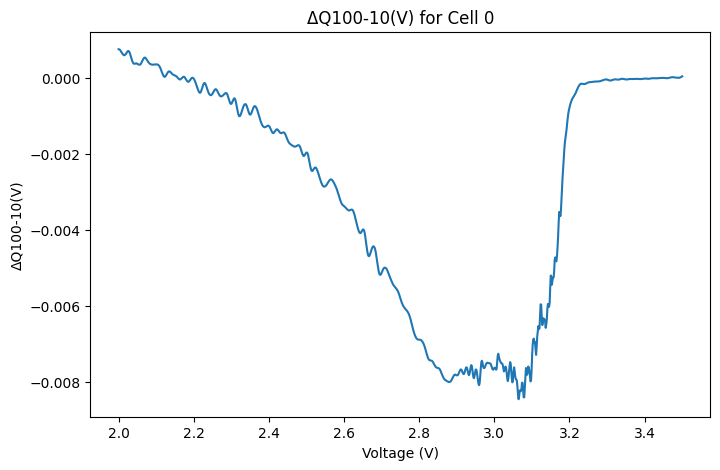

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(Vdlin, delta_Q)

plt.xlabel("Voltage (V)")
plt.ylabel("ΔQ100-10(V)")
plt.title("ΔQ100-10(V) for Cell 0")

plt.show()

In [45]:
cell0_feature_df = pd.DataFrame({
    "cell_index": [cell_index],
    "var_delta_Q": [var_delta_Q],
    "log_var_delta_Q": [log_var_delta_Q]
})

cell0_feature_df

,cell_index,var_delta_Q,log_var_delta_Q
0,0,0.00001,-5.014861


In [46]:
with h5py.File(batch1_path, "r") as f:
    cycle_life_ref = f["batch"]["cycle_life"][cell_index, 0]
    cycle_life = np.array(f[cycle_life_ref]).squeeze()

cell0_feature_df = pd.DataFrame({
    "cell_index": [cell_index],
    "cycle_life": [float(cycle_life)],
    "var_delta_Q": [var_delta_Q],
    "log_var_delta_Q": [log_var_delta_Q]
})

cell0_feature_df

,cell_index,cycle_life,var_delta_Q,log_var_delta_Q
0,0,1190.0,0.00001,-5.014861


### Computing ΔQ100-10(V) for Cell 0

In this section, I compute the discharge curve change between Cycle 100 and Cycle 10 for Cell 0. I use `Qdlin` because it represents discharge capacity values aligned on a common voltage grid, which makes it easier to compare two cycles directly.

The feature is calculated as:

ΔQ100-10(V) = Q100(V) - Q10(V)

After computing this difference curve, I calculate its variance and take the log10 of the variance. This log variance feature is important because the paper shows that early-cycle discharge curve changes are strongly related to battery cycle life.

## Compute ΔQ100-10(V) for All Cells

Today, I apply the ΔQ100-10(V) feature extraction process to all usable battery cells. The goal is to compute the log variance of the discharge curve change between Cycle 100 and Cycle 10, then compare it with cycle life.

In [32]:
mat_files

['/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat',
 '/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-02-20_batchdata_updated_struct_errorcorrect.mat',
 '/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat',
 '/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-12_batchdata_updated_struct_errorcorrect.mat']

In [33]:
def read_scalar_from_ref(f, ref):
    value = np.array(f[ref]).squeeze()
    return float(value)

In [34]:
def compute_deltaQ_feature(file_path, cell_index):
    cycle_10_index = 9
    cycle_100_index = 99
    
    with h5py.File(file_path, "r") as f:
        # Read cycle life
        cycle_life_ref = f["batch"]["cycle_life"][cell_index, 0]
        cycle_life = read_scalar_from_ref(f, cycle_life_ref)
        
        # Open cycles data
        cycles_ref = f["batch"]["cycles"][cell_index, 0]
        cycles = f[cycles_ref]
        
        # Check if Qdlin exists
        if "Qdlin" not in cycles.keys():
            return None
        
        # Check if this cell has at least 100 cycles
        num_cycles = cycles["Qdlin"].shape[0]
        if num_cycles <= cycle_100_index:
            return None
        
        # Read Qdlin for Cycle 10 and Cycle 100
        Qdlin_10_ref = cycles["Qdlin"][cycle_10_index, 0]
        Qdlin_100_ref = cycles["Qdlin"][cycle_100_index, 0]
        
        Qdlin_10 = np.array(f[Qdlin_10_ref]).squeeze()
        Qdlin_100 = np.array(f[Qdlin_100_ref]).squeeze()
        
        # Check shape
        if Qdlin_10.shape != Qdlin_100.shape:
            return None
        
        # Compute delta Q
        delta_Q = Qdlin_100 - Qdlin_10
        
        # Check missing values
        if np.isnan(delta_Q).sum() > 0:
            return None
        
        # Compute variance and log variance
        var_delta_Q = np.var(delta_Q)
        
        if var_delta_Q <= 0:
            return None
        
        log_var_delta_Q = np.log10(var_delta_Q)
        
        return {
            "batch_file": os.path.basename(file_path),
            "cell_index": cell_index,
            "cycle_life": cycle_life,
            "var_delta_Q": var_delta_Q,
            "log_var_delta_Q": log_var_delta_Q
        }

In [35]:
test_result = compute_deltaQ_feature(mat_files[0], 0)

test_result

{'batch_file': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
 'cell_index': 0,
 'cycle_life': 1190.0,
 'var_delta_Q': np.float64(9.663600264771342e-06),
 'log_var_delta_Q': np.float64(-5.014861042960787)}

In [50]:
# Store successful feature extraction results here.
feature_results = []

# Store cells that cannot be used here.
# Some cells may be skipped because of missing data, incomplete cycles, or invalid Qdlin values.
skipped_cells = []

# Loop through every MATLAB batch file in the dataset.
for file_path in mat_files:
    
    # Get only the file name, not the full path.
    # This makes the final DataFrame easier to read.
    batch_name = os.path.basename(file_path)
    
    # Open the batch file once to find out how many cells it contains.
    with h5py.File(file_path, "r") as f:
        num_cells = f["batch"]["cycle_life"].shape[0]
    
    # Loop through every cell in this batch file.
    for cell_index in range(num_cells):
        try:
            # Try to compute the ΔQ100-10(V) feature for this cell.
            result = compute_deltaQ_feature(file_path, cell_index)
            
            # If the function returns a valid result, save it.
            if result is not None:
                feature_results.append(result)
            
            # If the function returns None, this cell is skipped.
            else:
                skipped_cells.append({
                    "batch_file": batch_name,
                    "cell_index": cell_index,
                    "reason": "missing data or invalid feature"
                })
        
        # If an error happens, record the cell and the error message.
        # This prevents one bad cell from stopping the whole loop.
        except Exception as e:
            skipped_cells.append({
                "batch_file": batch_name,
                "cell_index": cell_index,
                "reason": str(e)
            })

# Convert successful results into a DataFrame.
# Each row represents one usable battery cell and its extracted feature.
features_df = pd.DataFrame(feature_results)

# Convert skipped cell records into a DataFrame.
# This helps check how many cells were skipped and why.
skipped_df = pd.DataFrame(skipped_cells)

# Preview the extracted feature table.
features_df.head()

,batch_file,cell_index,cycle_life,var_delta_Q,log_var_delta_Q
0,2017-05-12_batchdata_updated_struct_errorcorre...,0,1190.0,0.000010,-5.014861
1,2017-05-12_batchdata_updated_struct_errorcorre...,1,1179.0,0.000010,-5.013960
2,2017-05-12_batchdata_updated_struct_errorcorre...,2,1177.0,0.000018,-4.737000
3,2017-05-12_batchdata_updated_struct_errorcorre...,3,1226.0,0.000036,-4.442613
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0,0.000023,-4.647744


In [37]:
features_df.shape

(141, 5)

In [38]:
features_df.head()

,batch_file,cell_index,cycle_life,var_delta_Q,log_var_delta_Q
0,2017-05-12_batchdata_updated_struct_errorcorre...,0,1190.0,0.000010,-5.014861
1,2017-05-12_batchdata_updated_struct_errorcorre...,1,1179.0,0.000010,-5.013960
2,2017-05-12_batchdata_updated_struct_errorcorre...,2,1177.0,0.000018,-4.737000
3,2017-05-12_batchdata_updated_struct_errorcorre...,3,1226.0,0.000036,-4.442613
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0,0.000023,-4.647744


In [39]:
features_df.describe()

,cell_index,cycle_life,var_delta_Q,log_var_delta_Q
count,141.000000,129.000000,141.000000,141.000000
mean,22.354610,833.689922,0.000198,-3.932900
std,13.585778,314.972737,0.000237,0.472303
min,0.000000,392.000000,0.000003,-5.600566
25%,11.000000,559.000000,0.000059,-4.231628
50%,22.000000,828.000000,0.000100,-4.000684
75%,34.000000,1017.000000,0.000305,-3.516252
max,46.000000,1935.000000,0.002066,-2.684918


In [40]:
skipped_df.shape

(0, 0)

In [41]:
features_df.isna().sum()

batch_file          0
cell_index          0
cycle_life         12
var_delta_Q         0
log_var_delta_Q     0
dtype: int64

In [43]:
features_df = features_df.dropna()

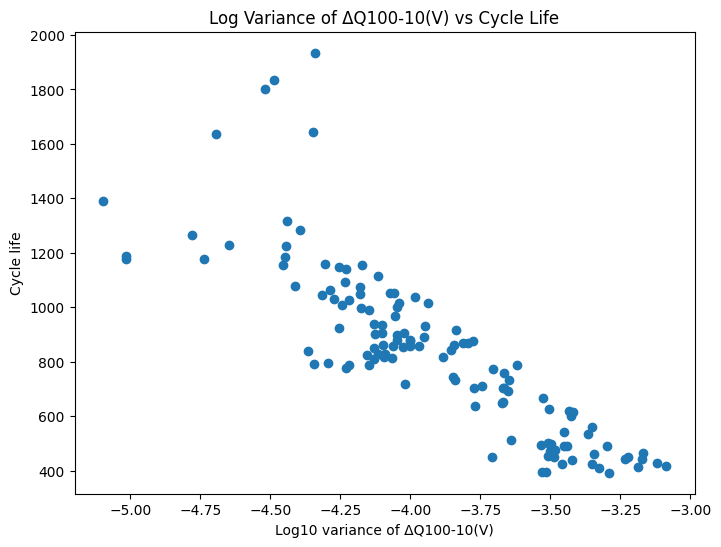

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(features_df["log_var_delta_Q"], features_df["cycle_life"])

plt.xlabel("Log10 variance of ΔQ100-10(V)")
plt.ylabel("Cycle life")
plt.title("Log Variance of ΔQ100-10(V) vs Cycle Life")

plt.show()

In [45]:
correlation = features_df["log_var_delta_Q"].corr(features_df["cycle_life"])

print("Correlation between log variance and cycle life:", correlation)

Correlation between log variance and cycle life: -0.8506086948396547


### Log Variance of ΔQ100-10(V) vs Cycle Life

This scatter plot compares the log10 variance of the discharge curve change between Cycle 100 and Cycle 10 with the cycle life of each usable battery cell.

For each cell, I computed:

ΔQ100-10(V) = Q100(V) - Q10(V)

Then I calculated the variance of this difference curve and took the log10 of the variance. This creates one numerical feature that summarizes how much the discharge curve changed during the early cycles.

The plot helps show whether larger early-cycle discharge curve changes are related to shorter battery lifetimes. This is the central idea of the paper, because early capacity fade alone may not clearly show future battery life, but voltage-capacity curve changes can contain useful aging information.

**Observation:**  
The scatter plot shows the relationship between early-cycle discharge curve change and cycle life. If the points show a negative trend, it means cells with larger ΔQ100-10(V) variance tend to have shorter cycle lives. This supports the paper's idea that subtle voltage-capacity curve changes in early cycles can be useful for predicting battery lifetime.

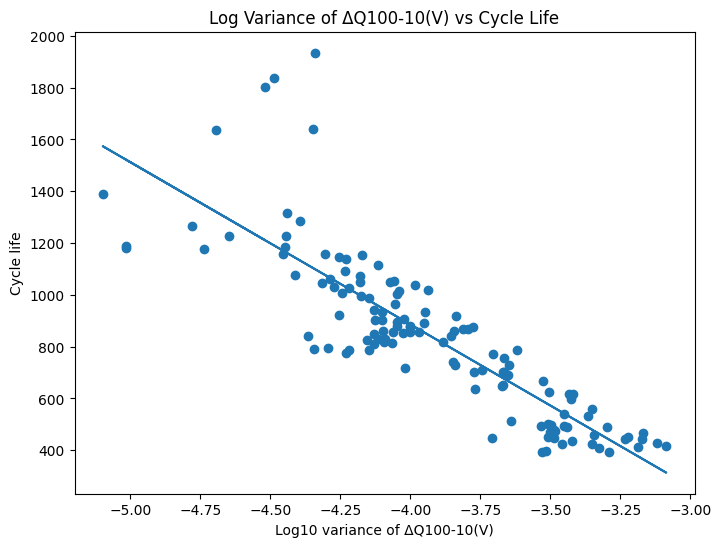

In [46]:
x = features_df["log_var_delta_Q"]
y = features_df["cycle_life"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 6))

plt.scatter(x, y)
plt.plot(x, m * x + b)

plt.xlabel("Log10 variance of ΔQ100-10(V)")
plt.ylabel("Cycle life")
plt.title("Log Variance of ΔQ100-10(V) vs Cycle Life")

plt.show()

In [48]:
features_df.to_csv("deltaQ_features_all_cells.csv", index=False)
skipped_df.to_csv("skipped_cells_deltaQ.csv", index=False)

In [49]:
os.listdir("/kaggle/working")

['skipped_cells_deltaQ.csv',
 'cycle_life_all_cells.csv',
 'deltaQ_features_all_cells.csv',
 '.virtual_documents']

## Final Scatter Plot and Notebook Cleanup

Today, I finish the central scatter plot from the paper and organize the notebook. The goal is to connect the log variance of ΔQ100-10(V) with battery cycle life and clearly explain the result.

In [51]:
features_df.head()

,batch_file,cell_index,cycle_life,var_delta_Q,log_var_delta_Q
0,2017-05-12_batchdata_updated_struct_errorcorre...,0,1190.0,0.000010,-5.014861
1,2017-05-12_batchdata_updated_struct_errorcorre...,1,1179.0,0.000010,-5.013960
2,2017-05-12_batchdata_updated_struct_errorcorre...,2,1177.0,0.000018,-4.737000
3,2017-05-12_batchdata_updated_struct_errorcorre...,3,1226.0,0.000036,-4.442613
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0,0.000023,-4.647744


In [52]:
features_df.shape

(141, 5)

In [53]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   batch_file       141 non-null    object 
 1   cell_index       141 non-null    int64  
 2   cycle_life       129 non-null    float64
 3   var_delta_Q      141 non-null    float64
 4   log_var_delta_Q  141 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 5.6+ KB


In [54]:
features_df.isna().sum()

batch_file          0
cell_index          0
cycle_life         12
var_delta_Q         0
log_var_delta_Q     0
dtype: int64

In [56]:
features_df = features_df.dropna()

In [57]:
features_df.isna().sum()

batch_file         0
cell_index         0
cycle_life         0
var_delta_Q        0
log_var_delta_Q    0
dtype: int64

### Checking Skipped Cells

Some cells may be skipped because they do not have complete Cycle 10 or Cycle 100 `Qdlin` data, or because the feature calculation is invalid. I keep track of skipped cells so I know how many cells were successfully used in the final analysis.

But there are no cells get skipped

In [58]:
skipped_df.shape

(0, 0)

In [60]:
features_df.describe()

,cell_index,cycle_life,var_delta_Q,log_var_delta_Q
count,129.000000,129.000000,129.000000,129.000000
mean,21.906977,833.689922,0.000187,-3.916885
std,13.512403,314.972737,0.000175,0.427685
min,0.000000,392.000000,0.000008,-5.098856
25%,10.000000,559.000000,0.000066,-4.178878
50%,21.000000,828.000000,0.000100,-3.999668
75%,33.000000,1017.000000,0.000305,-3.516252
max,46.000000,1935.000000,0.000821,-3.085882


In [61]:
print("Number of usable cells:", len(features_df))
print("Shortest cycle life:", features_df["cycle_life"].min())
print("Longest cycle life:", features_df["cycle_life"].max())
print("Smallest log variance:", features_df["log_var_delta_Q"].min())
print("Largest log variance:", features_df["log_var_delta_Q"].max())

Number of usable cells: 129
Shortest cycle life: 392.0
Longest cycle life: 1935.0
Smallest log variance: -5.098855849397497
Largest log variance: -3.085881724279185


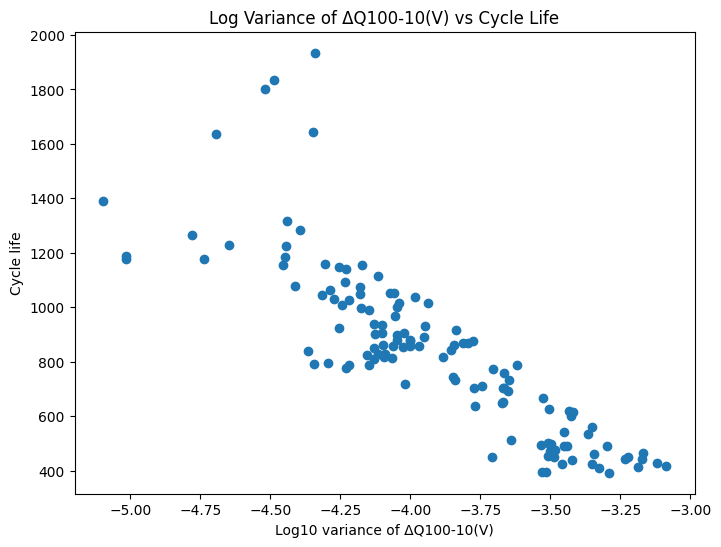

In [62]:
plt.figure(figsize=(8, 6))

plt.scatter(features_df["log_var_delta_Q"], features_df["cycle_life"])

plt.xlabel("Log10 variance of ΔQ100-10(V)")
plt.ylabel("Cycle life")
plt.title("Log Variance of ΔQ100-10(V) vs Cycle Life")

plt.show()

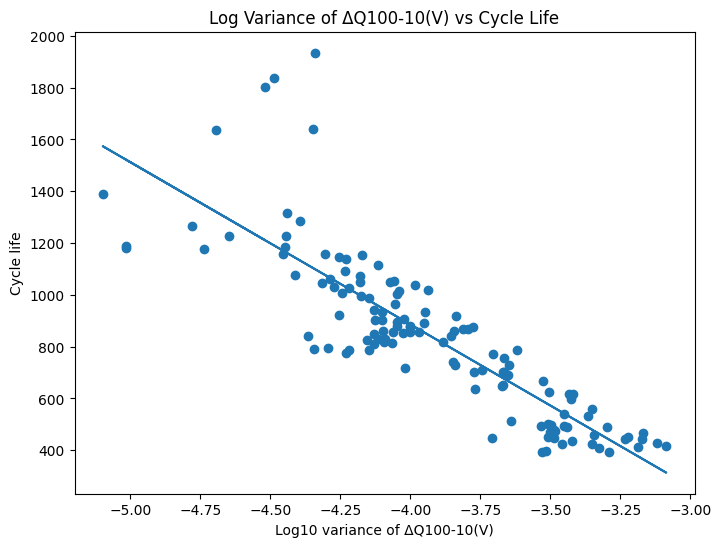

In [63]:
x = features_df["log_var_delta_Q"]
y = features_df["cycle_life"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 6))

plt.scatter(x, y)
plt.plot(x, m * x + b)

plt.xlabel("Log10 variance of ΔQ100-10(V)")
plt.ylabel("Cycle life")
plt.title("Log Variance of ΔQ100-10(V) vs Cycle Life")

plt.show()

In [64]:
features_df.to_csv("deltaQ_features_all_cells.csv", index=False)
skipped_df.to_csv("skipped_cells_deltaQ.csv", index=False)

In [65]:
import os

os.listdir("/kaggle/working")

['skipped_cells_deltaQ.csv',
 'cycle_life_all_cells.csv',
 'deltaQ_features_all_cells.csv',
 '.virtual_documents']

## Final Observations for this notebook

This week, I moved from single-cell exploration to dataset-level analysis. I first collected cycle life values across all available cells and plotted the distribution of battery lifetimes. This helped me understand that the dataset contains cells with a wide range of lifetimes.

I then computed the paper's central early-cycle feature: the log variance of ΔQ100-10(V). I first tested the calculation on one cell, then applied the same process to all usable cells. The final scatter plot compares this feature with cycle life.

This work helped me understand why early-cycle discharge voltage-capacity curve changes are important. Even when early capacity fade is small, the change in the discharge curve can still contain information related to future battery lifetime.